In [37]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [38]:
df = pd.read_csv(
    data_path,
    encoding="latin1",
    low_memory=False
)

print(df.shape)
df.head()

(133164, 178)


,entry_id,article_id,sample,analysis,latitude,longitude,sample_description,mag_det,material_analyzed,citation,method,age_method,comments,depth,country,craton,orogen,terrane,basin,region,lithology,suite_pluton_name,strat_unit,pb206_u238_age_2sd,pb206_u238_age_ma,pb207_pb206_age_2sd,pb207_pb206_age_ma,pb207_u235_age_2sd,pb207_u235_age_ma,pb208_th232_age_2sd,pb208_th232_age_ma,age,age_2sd,hf176_hf177,hf176_hf177_2sd,hf178_hf177,hf178_hf177_2sd,hf180_hf177,hf180_hf177_2sd,lu176_hf177,lu176_hf177_2sd,yb176_hf177,yb176_hf177_2sd,nd143_nd144,nd143_nd144_2sd,pb206_u238,pb206_u238_2sd,pb207_pb206,pb207_pb206_2sd,pb207_u235,pb207_u235_2sd,pb208_th232,pb208_th232_2sd,ag_ppm,al_ppm,as_ppm,au_ppm,b_ppm,ba_ppm,be_ppm,bi_ppm,br_ppm,c_ppm,ca_ppm,cd_ppm,ce_ppm,cl_ppm,co_ppm,cr_ppm,cs_ppm,cu_ppm,dy_ppm,er_ppm,eu_ppm,f_ppm,fe_ppm,ga_ppm,gd_ppm,ge_ppm,h_ppm,hf_ppm,hg_ppm,ho_ppm,i_ppm,in_ppm,ir_ppm,k_ppm,la_ppm,li_ppm,lu_ppm,mg_ppm,mn_ppm,mo_ppm,n_ppm,na_ppm,nb_ppm,nd_ppm,ni_ppm,os_ppm,p_ppm,pa_ppm,pb_ppm,pd_ppm,pm_ppm,pr_ppm,pt_ppm,rb_ppm,re_ppm,rh_ppm,ru_ppm,s_ppm,sb_ppm,sc_ppm,se_ppm,si_ppm,sm_ppm,sn_ppm,sr_ppm,ta_ppm,tb_ppm,te_ppm,th_ppm,ti_ppm,tl_ppm,tm_ppm,u_ppm,v_ppm,w_ppm,y_ppm,yb_ppm,zn_ppm,zr_ppm,continent,pb206_pb207,pb206_pb207_2sd,pb206_207Pb_ma,pb206_207Pb_ma_2sd,pbc_206_pc,do18m,do18m_2sd,do18n,do19n_2sd,pb206_pb204,pb206_pb204_2sd,pb207_pb204,pb207_pb204_2sd,pb208_pb204,pb208_pb204_2sd,rb87_sr86,rb87_sr86_2sd,rb87_sr87,rb87_sr87_2sd,th232_pb204,th232_pb204_2sd,th232_u238,th232_u238_2sd,u238_pb204,u238_pb204_2sd,u238_pb206,u238_pb206_2sd,rho_207pb235u_206pb238u,rho_206pb238u_207pb235u,u238_th232,u238_th232_2sd,pb208_pb206,o16_o18,o18_o16,o18_o16_2sd,u238_pb206_age_ma,u238_pb206_age_2sd,rho_238u206pb_207pb206pb,th_u,elevation,facies,yb176_lu176_hf176pc,volts_hf,do18n_2sd,doi
0,1,1132661,BLT01,3.1,NaN,NaN,NaN,magmatic,zircon,Zircon ages and Hf isotopic compositions of pl...,SHRIMP,NaN,common Pb corrected ratios and ages,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gabbro,NaN,NaN,33.0,435.0,763.0,763.0,143,492.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0698,0.0054,0.0647,0.0209,0.623,0.213,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9,NaN,NaN,NaN,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.6084/m9.figshare.1132661.v1
1,2,1132661,BLT01,10.1,NaN,NaN,NaN,magmatic,zircon,Zircon ages and Hf isotopic compositions of pl...,SHRIMP,NaN,common Pb corrected ratios and ages,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gabbro,NaN,NaN,30.0,455.0,102.0,629.0,34,485.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0731,0.0049,0.0607,0.0028,0.612,0.053,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,132,NaN,NaN,NaN,227.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.6084/m9.figshare.1132661.v1
2,3,1132661,BLT01,9.1,NaN,NaN,NaN,magmatic,zircon,Zircon ages and Hf isotopic compositions of pl...,SHRIMP,NaN,common Pb corrected ratios and ages,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gabbro,NaN,NaN,12.0,441.0,91.0,614.0,20,470.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0709,0.0020,0.0603,0.0025,0.589,0.031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [39]:
pd.set_option("display.max_columns", None)

df.columns.tolist()

['entry_id',
 'article_id',
 'sample',
 'analysis',
 'latitude',
 'longitude',
 'sample_description',
 'mag_det',
 'material_analyzed',
 'citation',
 'method',
 'age_method',
 'comments',
 'depth',
 'country',
 'craton',
 'orogen',
 'terrane',
 'basin',
 'region',
 'lithology',
 'suite_pluton_name',
 'strat_unit',
 'pb206_u238_age_2sd',
 'pb206_u238_age_ma',
 'pb207_pb206_age_2sd',
 'pb207_pb206_age_ma',
 'pb207_u235_age_2sd',
 'pb207_u235_age_ma',
 'pb208_th232_age_2sd',
 'pb208_th232_age_ma',
 'age',
 'age_2sd',
 'hf176_hf177',
 'hf176_hf177_2sd',
 'hf178_hf177',
 'hf178_hf177_2sd',
 'hf180_hf177',
 'hf180_hf177_2sd',
 'lu176_hf177',
 'lu176_hf177_2sd',
 'yb176_hf177',
 'yb176_hf177_2sd',
 'nd143_nd144',
 'nd143_nd144_2sd',
 'pb206_u238',
 'pb206_u238_2sd',
 'pb207_pb206',
 'pb207_pb206_2sd',
 'pb207_u235',
 'pb207_u235_2sd',
 'pb208_th232',
 'pb208_th232_2sd',
 'ag_ppm',
 'al_ppm',
 'as_ppm',
 'au_ppm',
 'b_ppm',
 'ba_ppm',
 'be_ppm',
 'bi_ppm',
 'br_ppm',
 'c_ppm',
 'ca_ppm',
 'cd_

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133164 entries, 0 to 133163
Columns: 178 entries, entry_id to doi
dtypes: float64(141), int64(2), object(35)
memory usage: 180.8+ MB


In [41]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing.head(40)

nd143_nd144_2sd    100.0
nd143_nd144        100.0
facies             100.0
sn_ppm             100.0
te_ppm             100.0
tl_ppm             100.0
v_ppm              100.0
w_ppm              100.0
do19n_2sd          100.0
u238_pb204         100.0
u238_pb204_2sd     100.0
th232_pb204_2sd    100.0
rb87_sr87_2sd      100.0
th232_pb204        100.0
rb87_sr87          100.0
rb87_sr86_2sd      100.0
rb87_sr86          100.0
pb208_pb204_2sd    100.0
i_ppm              100.0
in_ppm             100.0
ir_ppm             100.0
mg_ppm             100.0
ni_ppm             100.0
n_ppm              100.0
mn_ppm             100.0
se_ppm             100.0
re_ppm             100.0
rh_ppm             100.0
ru_ppm             100.0
pt_ppm             100.0
pd_ppm             100.0
pm_ppm             100.0
pa_ppm             100.0
os_ppm             100.0
s_ppm              100.0
cl_ppm             100.0
cr_ppm             100.0
co_ppm             100.0
ge_ppm             100.0
h_ppm              100.0


In [42]:
missing = df.isna().mean().sort_values(ascending=False) * 100

# colunas com MENOS dados faltantes
missing.tail(60)


hf178_hf177_2sd            93.841429
rho_206pb238u_207pb235u    93.740050
pr_ppm                     93.635667
tb_ppm                     93.483224
tm_ppm                     93.480971
ho_ppm                     93.352558
lu_ppm                     93.266949
nd_ppm                     92.742032
eu_ppm                     92.679703
ce_ppm                     92.654922
gd_ppm                     92.594095
er_ppm                     92.588838
sm_ppm                     92.573819
dy_ppm                     92.540777
yb_ppm                     92.395843
hf178_hf177                91.457151
pbc_206_pc                 90.001802
yb176_hf177_2sd            88.894897
age_2sd                    87.710643
yb176_hf177                84.458262
lu176_hf177_2sd            83.955123
sample_description         83.550359
terrane                    83.273257
pb_ppm                     81.493497
pb206_pb204                78.503199
country                    77.875402
age                        77.068877
h

In [43]:
good_cols = missing[missing < 50].index.tolist()

print(len(good_cols))
good_cols


21


['u_ppm',
 'pb207_pb206',
 'pb207_pb206_2sd',
 'pb207_u235',
 'pb207_u235_age_ma',
 'pb207_u235_2sd',
 'pb206_u238_2sd',
 'pb207_u235_age_2sd',
 'pb206_u238',
 'pb207_pb206_age_ma',
 'pb207_pb206_age_2sd',
 'pb206_u238_age_2sd',
 'pb206_u238_age_ma',
 'analysis',
 'sample',
 'doi',
 'article_id',
 'material_analyzed',
 'citation',
 'mag_det',
 'entry_id']

In [44]:
# Coluna alvo principal
target_age_col = "pb206_u238_age_ma"

# Colunas geoquímicas candidatas, sem usar razões U-Pb como entrada
geo_candidate_cols = [
    "u_ppm", "th_ppm",
    "hf176_hf177", "hf178_hf177",
    "lu176_hf177", "yb176_hf177",
    "la_ppm", "ce_ppm", "pr_ppm", "nd_ppm", "sm_ppm",
    "eu_ppm", "gd_ppm", "tb_ppm", "dy_ppm", "ho_ppm",
    "er_ppm", "tm_ppm", "yb_ppm", "lu_ppm",
    "hf_ppm", "ti_ppm", "y_ppm", "nb_ppm", "ta_ppm"
]

# Ficar só com colunas que realmente existem no dataframe
geo_candidate_cols = [col for col in geo_candidate_cols if col in df.columns]

print("Colunas geoquímicas encontradas:")
print(geo_candidate_cols)

# Linhas com idade conhecida
df_age = df.dropna(subset=[target_age_col]).copy()

print("Linhas com idade:", df_age.shape[0])

# Ver preenchimento das geoquímicas dentro das linhas com idade
geo_missing_age_subset = df_age[geo_candidate_cols].isna().mean().sort_values() * 100
geo_missing_age_subset

Colunas geoquímicas encontradas:
['u_ppm', 'th_ppm', 'hf176_hf177', 'hf178_hf177', 'lu176_hf177', 'yb176_hf177', 'la_ppm', 'ce_ppm', 'pr_ppm', 'nd_ppm', 'sm_ppm', 'eu_ppm', 'gd_ppm', 'tb_ppm', 'dy_ppm', 'ho_ppm', 'er_ppm', 'tm_ppm', 'yb_ppm', 'lu_ppm', 'hf_ppm', 'ti_ppm', 'y_ppm', 'nb_ppm', 'ta_ppm']
Linhas com idade: 94214


u_ppm          29.780075
th_ppm         45.807417
hf176_hf177    89.891099
lu176_hf177    89.891099
yb176_hf177    91.386630
yb_ppm         95.766022
dy_ppm         95.774513
ce_ppm         95.802110
sm_ppm         95.810601
eu_ppm         95.829707
er_ppm         95.842444
gd_ppm         95.846689
nd_ppm         95.915681
la_ppm         96.303097
hf178_hf177    96.321141
ti_ppm         96.430467
hf_ppm         96.470801
y_ppm          96.832742
lu_ppm         96.864585
ho_ppm         96.921901
tm_ppm         96.969665
tb_ppm         96.970726
pr_ppm         97.117201
nb_ppm         98.245484
ta_ppm         98.497039
dtype: float64

In [45]:
# Quantidade de variáveis geoquímicas preenchidas por linha
df_age["n_geo_features"] = df_age[geo_candidate_cols].notna().sum(axis=1)

df_age["n_geo_features"].value_counts().sort_index()

n_geo_features
0     26115
1     12514
2     42961
3      1362
4       736
5      5628
6       927
7         1
8         1
10       14
11       40
12        9
13       31
14     1131
15      229
16       90
17       71
18      601
19      184
20      485
21      724
22      120
23        4
24      215
25       21
Name: count, dtype: int64

In [46]:
for n in [1, 2, 3, 5, 8, 10]:
    count = (df_age["n_geo_features"] >= n).sum()
    print(f"Linhas com pelo menos {n} variáveis geoquímicas: {count}")

Linhas com pelo menos 1 variáveis geoquímicas: 68099
Linhas com pelo menos 2 variáveis geoquímicas: 55585
Linhas com pelo menos 3 variáveis geoquímicas: 12624
Linhas com pelo menos 5 variáveis geoquímicas: 10526
Linhas com pelo menos 8 variáveis geoquímicas: 3970
Linhas com pelo menos 10 variáveis geoquímicas: 3969


In [47]:
# Escolher subconjunto com dados geoquímicos suficientes
min_geo_features = 5

model_df = df_age[df_age["n_geo_features"] >= min_geo_features].copy()

print("Linhas no dataset de ML:", model_df.shape[0])
print("Colunas:", model_df.shape[1])

Linhas no dataset de ML: 10526
Colunas: 179


In [48]:
def classify_age(age):
    if pd.isna(age):
        return np.nan
    elif age < 250:
        return "0-250 Ma"
    elif age < 541:
        return "250-541 Ma"
    elif age < 1000:
        return "541-1000 Ma"
    elif age < 1600:
        return "1000-1600 Ma"
    elif age < 2500:
        return "1600-2500 Ma"
    else:
        return ">2500 Ma"

model_df["age_class"] = model_df[target_age_col].apply(classify_age)

model_df["age_class"].value_counts()

age_class
0-250 Ma        3063
541-1000 Ma     2371
250-541 Ma      1755
1600-2500 Ma    1286
1000-1600 Ma    1153
>2500 Ma         898
Name: count, dtype: int64

In [49]:
for col in geo_candidate_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")


# Evitar divisões por zero
model_df["th_u_ratio"] = np.where(
    model_df["u_ppm"] > 0,
    model_df["th_ppm"] / model_df["u_ppm"],
    np.nan
)

if "ce_ppm" in model_df.columns and "yb_ppm" in model_df.columns:
    model_df["ce_yb_ratio"] = np.where(
        model_df["yb_ppm"] > 0,
        model_df["ce_ppm"] / model_df["yb_ppm"],
        np.nan
    )

if "nb_ppm" in model_df.columns and "ta_ppm" in model_df.columns:
    model_df["nb_ta_ratio"] = np.where(
        model_df["ta_ppm"] > 0,
        model_df["nb_ppm"] / model_df["ta_ppm"],
        np.nan
    )

if "lu_ppm" in model_df.columns and "hf_ppm" in model_df.columns:
    model_df["lu_hf_ratio"] = np.where(
        model_df["hf_ppm"] > 0,
        model_df["lu_ppm"] / model_df["hf_ppm"],
        np.nan
    )

feature_cols = geo_candidate_cols + [
    "th_u_ratio",
    "ce_yb_ratio",
    "nb_ta_ratio",
    "lu_hf_ratio"
]

feature_cols = [col for col in feature_cols if col in model_df.columns]

# Remover features muito vazias dentro do subconjunto
feature_missing = model_df[feature_cols].isna().mean() * 100
feature_cols = feature_missing[feature_missing < 80].index.tolist()

print("Features finais:", len(feature_cols))
print(feature_cols)

X = model_df[feature_cols].copy()
y = model_df["age_class"].copy()


Features finais: 26
['u_ppm', 'th_ppm', 'hf176_hf177', 'hf178_hf177', 'lu176_hf177', 'yb176_hf177', 'la_ppm', 'ce_ppm', 'pr_ppm', 'nd_ppm', 'sm_ppm', 'eu_ppm', 'gd_ppm', 'tb_ppm', 'dy_ppm', 'ho_ppm', 'er_ppm', 'tm_ppm', 'yb_ppm', 'lu_ppm', 'hf_ppm', 'ti_ppm', 'y_ppm', 'th_u_ratio', 'ce_yb_ratio', 'lu_hf_ratio']


In [50]:
y.value_counts(normalize=True) * 100

age_class
0-250 Ma        29.099373
541-1000 Ma     22.525176
250-541 Ma      16.673000
1600-2500 Ma    12.217367
1000-1600 Ma    10.953829
>2500 Ma         8.531256
Name: proportion, dtype: float64

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.7782526115859449

              precision    recall  f1-score   support

    0-250 Ma       0.90      0.95      0.92       613
1000-1600 Ma       0.61      0.50      0.55       231
1600-2500 Ma       0.77      0.81      0.79       257
  250-541 Ma       0.73      0.64      0.68       351
 541-1000 Ma       0.69      0.73      0.71       474
    >2500 Ma       0.87      0.90      0.89       180

    accuracy                           0.78      2106
   macro avg       0.76      0.76      0.76      2106
weighted avg       0.77      0.78      0.77      2106



In [52]:
classes = model.named_steps["classifier"].classes_

cm = confusion_matrix(y_test, y_pred, labels=classes)

cm_df = pd.DataFrame(
    cm,
    index=[f"Real: {c}" for c in classes],
    columns=[f"Previsto: {c}" for c in classes]
)

cm_df

,Previsto: 0-250 Ma,Previsto: 1000-1600 Ma,Previsto: 1600-2500 Ma,Previsto: 250-541 Ma,Previsto: 541-1000 Ma,Previsto: >2500 Ma
Real: 0-250 Ma,581,1,1,20,10,0
Real: 1000-1600 Ma,12,115,34,9,60,1
Real: 1600-2500 Ma,4,12,209,3,8,21
Real: 250-541 Ma,31,11,6,225,77,1
Real: 541-1000 Ma,16,49,9,52,347,1
Real: >2500 Ma,3,0,14,1,0,162


In [53]:
rf = model.named_steps["classifier"]

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(30)

,feature,importance
2,hf176_hf177,0.300927
0,u_ppm,0.084687
1,th_ppm,0.076694
5,yb176_hf177,0.075011
23,th_u_ratio,0.074644
4,lu176_hf177,0.068324
3,hf178_hf177,0.049932
21,ti_ppm,0.021524
10,sm_ppm,0.020198
9,nd_ppm,0.017338


In [54]:
import re
import numpy as np

def converter_idade(valor):
    valor = str(valor)

    numeros = re.findall(r'\d+', valor)

    if len(numeros) == 2:
        return (float(numeros[0]) + float(numeros[1])) / 2
    
    elif len(numeros) == 1:
        return float(numeros[0])
    
    else:
        return np.nan







for col in geo_candidate_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")


# Evitar divisões por zero
model_df["th_u_ratio"] = np.where(
    model_df["u_ppm"] > 0,
    model_df["th_ppm"] / model_df["u_ppm"],
    np.nan
)

if "ce_ppm" in model_df.columns and "yb_ppm" in model_df.columns:
    model_df["ce_yb_ratio"] = np.where(
        model_df["yb_ppm"] > 0,
        model_df["ce_ppm"] / model_df["yb_ppm"],
        np.nan
    )

if "nb_ppm" in model_df.columns and "ta_ppm" in model_df.columns:
    model_df["nb_ta_ratio"] = np.where(
        model_df["ta_ppm"] > 0,
        model_df["nb_ppm"] / model_df["ta_ppm"],
        np.nan
    )

if "lu_ppm" in model_df.columns and "hf_ppm" in model_df.columns:
    model_df["lu_hf_ratio"] = np.where(
        model_df["hf_ppm"] > 0,
        model_df["lu_ppm"] / model_df["hf_ppm"],
        np.nan
    )

feature_cols = geo_candidate_cols + [
    "th_u_ratio",
    "ce_yb_ratio",
    "nb_ta_ratio",
    "lu_hf_ratio"
]

feature_cols = [col for col in feature_cols if col in model_df.columns]

# Remover features muito vazias dentro do subconjunto
feature_missing = model_df[feature_cols].isna().mean() * 100
feature_cols = feature_missing[feature_missing < 80].index.tolist()

print("Features finais:", len(feature_cols))
print(feature_cols)
df["Age_numeric"] = df["age"].apply(converter_idade)
X = df.drop(columns=["age", "Age_numeric"])
y = df["Age_numeric"]

Features finais: 26
['u_ppm', 'th_ppm', 'hf176_hf177', 'hf178_hf177', 'lu176_hf177', 'yb176_hf177', 'la_ppm', 'ce_ppm', 'pr_ppm', 'nd_ppm', 'sm_ppm', 'eu_ppm', 'gd_ppm', 'tb_ppm', 'dy_ppm', 'ho_ppm', 'er_ppm', 'tm_ppm', 'yb_ppm', 'lu_ppm', 'hf_ppm', 'ti_ppm', 'y_ppm', 'th_u_ratio', 'ce_yb_ratio', 'lu_hf_ratio']


In [55]:
def training(X_train, y_train, param_dist=None):
    print("Começando treinamento...")

    if param_dist is None:
        param_dist = {
            "n_estimators": [100, 200, 300],
            "max_depth": [10, 15, 20, None],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4]
        }

    rf = RandomForestRegressor(random_state=42, n_jobs=-1)

    search = RandomizedSearchCV(
        rf,
        param_distributions=param_dist,
        n_iter=10,
        scoring="neg_mean_absolute_error",
        cv=3,
        random_state=42,
        verbose=2
    )

    search.fit(X_train, y_train)

    print("Melhores parâmetros:")
    print(search.best_params_)

    return search

In [56]:
df.columns = df.columns.str.strip()

df["Age_numeric"] = df["age"]

# Remove linhas sem idade
df_model = df.dropna(subset=["Age_numeric"]).copy()

# Pega só colunas numéricas
X = df_model.select_dtypes(include=["number"]).copy()

# Remove a idade e colunas que vazam diretamente a resposta
cols_to_remove = [
    "age",
    "age_2sd",
    "Age_numeric",
    "pb206_u238_age_ma",
    "pb207_pb206_age_ma",
    "pb207_u235_age_ma",
    "pb208_th232_age_ma",
    "u238_pb206_age_ma",
    "pb206_207Pb_ma"
]

X = X.drop(columns=[col for col in cols_to_remove if col in X.columns])

y = df_model["Age_numeric"]


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [57]:
model_search = training(X_train, y_train)

Começando treinamento...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=300; total time=   8.1s
[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=300; total time=   7.9s
[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=300; total time=   7.8s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=  41.0s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time= -33.1s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=   3.9s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   3.9s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   3.9s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   3.9s
[CV] 

In [58]:
df.columns = df.columns.str.strip()

df["Age_numeric"] = df["age"]

# Remove linhas sem idade
df_model = df.dropna(subset=["Age_numeric"]).copy()

# Pega só colunas numéricas
X = df_model.select_dtypes(include=["number"]).copy()

# Remove a idade e colunas que vazam diretamente a resposta
cols_to_remove = [
    "age",
    "age_2sd",
    "Age_numeric",
    "pb206_u238_age_ma",
    "pb207_pb206_age_ma",
    "pb207_u235_age_ma",
    "pb208_th232_age_ma",
    "u238_pb206_age_ma",
    "pb206_207Pb_ma"
]

X = X.drop(columns=[col for col in cols_to_remove if col in X.columns])

y = df_model["Age_numeric"]

In [59]:
best_model = model_search.best_estimator_

from sklearn.metrics import mean_absolute_error, r2_score

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R²:", r2)

MAE: 100.4501362698601
R²: 0.9389853792089949


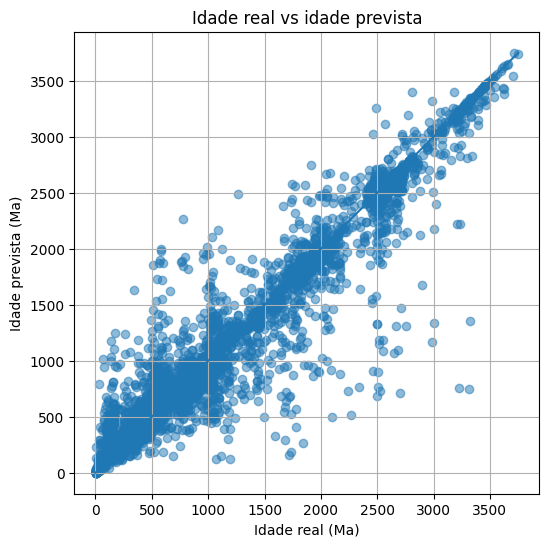

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Idade real (Ma)")
plt.ylabel("Idade prevista (Ma)")
plt.title("Idade real vs idade prevista")
plt.grid(True)
plt.show()

In [63]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

best_model = model_search.best_estimator_

y_pred = best_model.predict(X_test)

y_test_class = y_test.apply(classify_age)
y_pred_class = pd.Series(y_pred).apply(classify_age)

labels = [
    "0-250 Ma",
    "250-541 Ma",
    "541-1000 Ma",
    "1000-1600 Ma",
    "1600-2500 Ma",
    ">2500 Ma"
]

acc = accuracy_score(y_test_class, y_pred_class)

print("Accuracy:", acc)
print()
print(classification_report(
    y_test_class,
    y_pred_class,
    labels=labels
))

cm = confusion_matrix(y_test_class, y_pred_class, labels=labels)

cm_df = pd.DataFrame(
    cm,
    index=[f"Real {label}" for label in labels],
    columns=[f"Previsto {label}" for label in labels]
)

cm_df

Accuracy: 0.8407007203667322

              precision    recall  f1-score   support

    0-250 Ma       0.97      0.89      0.93      1752
  250-541 Ma       0.83      0.86      0.84      1290
 541-1000 Ma       0.73      0.86      0.79       973
1000-1600 Ma       0.72      0.71      0.71       642
1600-2500 Ma       0.80      0.79      0.80       788
    >2500 Ma       0.92      0.83      0.87       663

    accuracy                           0.84      6108
   macro avg       0.83      0.82      0.82      6108
weighted avg       0.85      0.84      0.84      6108



,Previsto 0-250 Ma,Previsto 250-541 Ma,Previsto 541-1000 Ma,Previsto 1000-1600 Ma,Previsto 1600-2500 Ma,Previsto >2500 Ma
Real 0-250 Ma,1563,156,28,5,0,0
Real 250-541 Ma,36,1110,128,14,2,0
Real 541-1000 Ma,3,51,834,66,19,0
Real 1000-1600 Ma,3,17,129,454,39,0
Real 1600-2500 Ma,2,6,24,80,625,51
Real >2500 Ma,0,0,6,12,96,549
